# EEG Signal Denoising — Wavelet Transform Baseline
 
→ `Biorthogonal` wavelet + **hard** thresholding

**Metrics computed:**
- MSE (Mean Squared Error)
- RMSE
- SNR (Signal-to-Noise Ratio, dB)
- RRMSE (Relative RMSE)
- **Spectral Loss** — MSE in the frequency domain (FFT magnitude)

---
All 7 artifact combinations × 3 splits (train / val / test) are processed.

## 1 — Install / Import

In [1]:
# Standard Kaggle environment already has everything we need.
# Uncomment the line below only if PyWavelets is missing.
# !pip install PyWavelets -q

import os
import glob
import warnings
import numpy as np
import pandas as pd
import pywt
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import fft, fftfreq
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('PyWavelets version :', pywt.__version__)
print('NumPy version      :', np.__version__)
print('h5py  version      :', h5py.__version__)

PyWavelets version : 1.8.0
NumPy version      : 2.0.2
h5py  version      : 3.15.1


## 2 — Configuration

In [2]:
# ── Dataset path ────────────────────────────────────────────────────────────
# Adjust INPUT_DIR to wherever your HDF5 files sit in Kaggle.
# Typical layout after adding the dataset:
#   /kaggle/input/<dataset-slug>/{combo}_{split}.h5
INPUT_DIR = '/kaggle/input/datasets/lucky3663/eegdenoise'  # <-- change if needed

OUTPUT_DIR = '/kaggle/working/wt_denoising_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Wavelet config (best from Table I of the paper) ─────────────────────────
WAVELET       = 'bior2.2'       # Biorthogonal (bior family in PyWavelets)
THRESHOLD_TYPE = 'hard'         # 'hard' or 'soft'
DECOMP_LEVEL  = 4               # Decomposition levels (tunable)
THRESHOLD_RULE = 'universal'    # universal (VisuShrink) threshold

# ── Dataset structure ───────────────────────────────────────────────────────
COMBOS = ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']
SPLITS = ['train', 'val', 'test']

FS = 256  # sampling frequency (Hz) — from dataset_context.md

print(f'Wavelet      : {WAVELET}')
print(f'Threshold    : {THRESHOLD_TYPE}')
print(f'Decomp levels: {DECOMP_LEVEL}')
print(f'Input dir    : {INPUT_DIR}')
print(f'Output dir   : {OUTPUT_DIR}')

Wavelet      : bior2.2
Threshold    : hard
Decomp levels: 4
Input dir    : /kaggle/input/datasets/lucky3663/eegdenoise
Output dir   : /kaggle/working/wt_denoising_results


## 3 — Helper Functions

In [3]:
# ──────────────────────────────────────────────────────────────────────────
# 3-A  Universal (VisuShrink) threshold
# ──────────────────────────────────────────────────────────────────────────
def universal_threshold(detail_coeffs: np.ndarray) -> float:
    """
    VisuShrink threshold:  λ = σ̂ * √(2 ln N)
    where σ̂ is estimated from the finest-level detail coefficients
    using the MAD estimator (robust to outliers).
    """
    N = len(detail_coeffs)
    sigma = np.median(np.abs(detail_coeffs)) / 0.6745
    return sigma * np.sqrt(2 * np.log(N))


# ──────────────────────────────────────────────────────────────────────────
# 3-B  Single-signal DWT denoising
# ──────────────────────────────────────────────────────────────────────────
def wavelet_denoise(
    signal: np.ndarray,
    wavelet: str = WAVELET,
    level: int = DECOMP_LEVEL,
    mode: str = THRESHOLD_TYPE,
) -> np.ndarray:
    """
    Denoise a 1-D signal using DWT + thresholding + IDWT.

    Steps (as described in the paper §III-B):
      1. Decompose with DWT.
      2. Compute universal threshold from finest detail level.
      3. Apply hard/soft threshold to all detail sub-bands.
      4. Reconstruct with IDWT.
    """
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    # coeffs[0]  = approximation (cA)  ← leave untouched
    # coeffs[1:] = detail levels cD1 … cDN  ← threshold these

    # Estimate threshold from finest detail level
    threshold = universal_threshold(coeffs[-1])

    # Threshold all detail sub-bands
    denoised_coeffs = [coeffs[0]]  # keep approximation
    for detail in coeffs[1:]:
        denoised_coeffs.append(
            pywt.threshold(detail, threshold, mode=mode)
        )

    # Reconstruct
    reconstructed = pywt.waverec(denoised_coeffs, wavelet)
    # Trim to original length (IDWT may add 1 sample due to boundary)
    return reconstructed[:len(signal)]


# ──────────────────────────────────────────────────────────────────────────
# 3-C  Metric functions
# ──────────────────────────────────────────────────────────────────────────
def compute_mse(clean: np.ndarray, denoised: np.ndarray) -> float:
    return float(np.mean((clean - denoised) ** 2))


def compute_rmse(clean: np.ndarray, denoised: np.ndarray) -> float:
    return float(np.sqrt(compute_mse(clean, denoised)))


def compute_snr(clean: np.ndarray, denoised: np.ndarray) -> float:
    """
    SNR (dB) = 10 * log10( power(clean) / power(error) )
    """
    signal_power = np.mean(clean ** 2)
    noise_power  = np.mean((clean - denoised) ** 2)
    if noise_power == 0:
        return float('inf')
    return float(10 * np.log10(signal_power / noise_power))


def compute_rrmse(clean: np.ndarray, denoised: np.ndarray) -> float:
    """
    Relative RMSE = RMSE / RMS(clean)
    """
    rms_clean = np.sqrt(np.mean(clean ** 2))
    if rms_clean == 0:
        return float('nan')
    return float(compute_rmse(clean, denoised) / rms_clean)


def compute_spectral_loss(clean: np.ndarray, denoised: np.ndarray) -> float:
    """
    Spectral Loss = MSE between FFT magnitude spectra.

    Captures differences in the frequency-domain content, penalising
    over-smoothing (loss of high-frequency signal energy) and
    residual artefact frequencies that time-domain MSE can miss.
    """
    mag_clean   = np.abs(fft(clean))
    mag_denoised = np.abs(fft(denoised))
    return float(np.mean((mag_clean - mag_denoised) ** 2))


def evaluate_batch(
    clean_batch: np.ndarray,
    denoised_batch: np.ndarray,
) -> dict:
    """
    Aggregate metrics over a 2-D batch (N, L).
    Returns mean of each metric across all N signals.
    """
    mses    = [compute_mse(c, d)           for c, d in zip(clean_batch, denoised_batch)]
    rmses   = [compute_rmse(c, d)          for c, d in zip(clean_batch, denoised_batch)]
    snrs    = [compute_snr(c, d)           for c, d in zip(clean_batch, denoised_batch)]
    rrmses  = [compute_rrmse(c, d)         for c, d in zip(clean_batch, denoised_batch)]
    spec_ls = [compute_spectral_loss(c, d) for c, d in zip(clean_batch, denoised_batch)]
    return {
        'MSE'           : np.mean(mses),
        'RMSE'          : np.mean(rmses),
        'SNR_dB'        : np.mean(snrs),
        'RRMSE'         : np.mean(rrmses),
        'Spectral_Loss' : np.mean(spec_ls),
    }

print('Helper functions defined.')

Helper functions defined.


## 4 — Batch Denoising Function

In [4]:
def denoise_split(
    combo: str,
    split: str,
    input_dir: str = INPUT_DIR,
) -> tuple[np.ndarray, np.ndarray, dict]:
    """
    Load one HDF5 file, run WT denoising on every signal, return metrics.

    Returns
    -------
    clean_arr    : (N, 512) ground-truth signals
    denoised_arr : (N, 512) WT-denoised signals
    metrics      : dict of mean metrics over the split
    """
    h5_path = os.path.join(input_dir, f'{combo}_{split}.h5')

    with h5py.File(h5_path, 'r') as f:
        clean_arr = f['clean'][:]   # (N, 512)
        noisy_arr = f['noisy'][:]   # (N, 512)

    N = len(noisy_arr)
    denoised_arr = np.empty_like(noisy_arr)

    for i in tqdm(range(N), desc=f'  {combo}/{split}', leave=False, unit='seg'):
        denoised_arr[i] = wavelet_denoise(noisy_arr[i])

    metrics = evaluate_batch(clean_arr, denoised_arr)
    return clean_arr, denoised_arr, metrics

print('denoise_split() defined.')

denoise_split() defined.


## 5 — Run Denoising Across All Combos and Splits

In [5]:
all_results = []          # list of dicts → DataFrame at the end
denoised_store = {}       # keep test-split arrays for visualisation
clean_store    = {}

outer_bar = tqdm(COMBOS, desc='Artifact combos', unit='combo')

for combo in outer_bar:
    outer_bar.set_postfix(combo=combo)
    for split in tqdm(SPLITS, desc=f'  Splits [{combo}]', leave=False, unit='split'):

        clean_arr, denoised_arr, metrics = denoise_split(combo, split)

        row = {'combo': combo, 'split': split, **metrics}
        all_results.append(row)

        # Save test arrays for plotting
        if split == 'test':
            clean_store[combo]    = clean_arr
            denoised_store[combo] = denoised_arr

        # Print inline summary
        tqdm.write(
            f"  [{combo:>11s} | {split:>5s}]  "
            f"MSE={metrics['MSE']:.5f}  "
            f"RMSE={metrics['RMSE']:.5f}  "
            f"SNR={metrics['SNR_dB']:+.2f} dB  "
            f"RRMSE={metrics['RRMSE']:.5f}  "
            f"SpectralLoss={metrics['Spectral_Loss']:.4f}"
        )

results_df = pd.DataFrame(all_results)
print('\n✓ All combos processed.')

Artifact combos:   0%|          | 0/7 [00:00<?, ?combo/s]

  Splits [emg]:   0%|          | 0/3 [00:00<?, ?split/s]

  emg/train:   0%|          | 0/36110 [00:00<?, ?seg/s]

  [        emg | train]  MSE=0.43491  RMSE=0.63961  SNR=-2.69 dB  RRMSE=1.65423  SpectralLoss=139.7521


  emg/val:   0%|          | 0/4510 [00:00<?, ?seg/s]

...

  [emg_eog_ecg | train]  MSE=0.86083  RMSE=0.92039  SNR=-9.09 dB  RRMSE=3.49801  SpectralLoss=327.0189


  emg_eog_ecg/val:   0%|          | 0/4510 [00:00<?, ?seg/s]

  [emg_eog_ecg |   val]  MSE=0.85068  RMSE=0.91474  SNR=-9.08 dB  RRMSE=3.49340  SpectralLoss=323.1271


  emg_eog_ecg/test:   0%|          | 0/4520 [00:00<?, ?seg/s]

  [emg_eog_ecg |  test]  MSE=0.86019  RMSE=0.91974  SNR=-9.04 dB  RRMSE=3.47607  SpectralLoss=326.9621

✓ All combos processed.


## 6 — Results Table

In [6]:
pd.set_option('display.float_format', '{:.5f}'.format)
print('=== All Metrics (Wavelet Transform — Biorthogonal / Hard Threshold) ===')
display(results_df)

# Save to CSV
csv_path = os.path.join(OUTPUT_DIR, 'wt_metrics_all.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nSaved → {csv_path}')

=== All Metrics (Wavelet Transform — Biorthogonal / Hard Threshold) ===


,combo,split,MSE,RMSE,SNR_dB,RRMSE,Spectral_Loss
0,emg,train,0.43491,0.63961,-2.69117,1.65423,139.75212
1,emg,val,0.43936,0.64449,-2.78310,1.67005,141.73138
2,emg,test,0.43021,0.63649,-2.66438,1.64672,137.72947
3,eog,train,0.72510,0.83797,-5.08745,2.20333,264.95455
4,eog,val,0.72887,0.83949,-5.08418,2.20296,265.53756
5,eog,test,0.71605,0.83284,-5.08682,2.20326,266.53622
6,ecg,train,1.49786,1.12354,-5.07898,2.20210,636.99795
7,ecg,val,1.48598,1.11891,-5.07805,2.20194,626.92112
8,ecg,test,1.48123,1.12098,-5.07910,2.20212,629.36189
9,emg_eog,train,0.65024,0.79951,-7.02357,2.74215,230.44684



Saved → /kaggle/working/wt_denoising_results/wt_metrics_all.csv


In [7]:
# ── Test-split summary (the split used for final evaluation) ────────────────
test_df = results_df[results_df['split'] == 'test'].copy().reset_index(drop=True)
test_df = test_df.drop(columns='split')
print('=== Test-Split Summary ===')
display(test_df)

# ── Global averages across all combos ───────────────────────────────────────
print('\n=== Global Mean (Test Split) ===')
display(test_df.drop(columns='combo').mean().to_frame(name='Mean').T)

=== Test-Split Summary ===


,combo,MSE,RMSE,SNR_dB,RRMSE,Spectral_Loss
0,emg,0.43021,0.63649,-2.66438,1.64672,137.72947
1,eog,0.71605,0.83284,-5.08682,2.20326,266.53622
2,ecg,1.48123,1.12098,-5.07910,2.20212,629.36189
3,emg_eog,0.65610,0.80331,-7.05298,2.75177,231.09227
4,emg_ecg,0.81171,0.88766,-7.02263,2.74030,306.36456
5,eog_ecg,1.04017,1.00446,-8.00301,3.10002,406.68256
6,emg_eog_ecg,0.86019,0.91974,-9.04370,3.47607,326.96207



=== Global Mean (Test Split) ===


,MSE,RMSE,SNR_dB,RRMSE,Spectral_Loss
Mean,0.85652,0.88650,-6.27895,2.58861,329.24700


## 7 — Visualisation
### 7-A  Time-domain reconstruction examples

Plotting time-domain:   0%|          | 0/7 [00:00<?, ?combo/s]

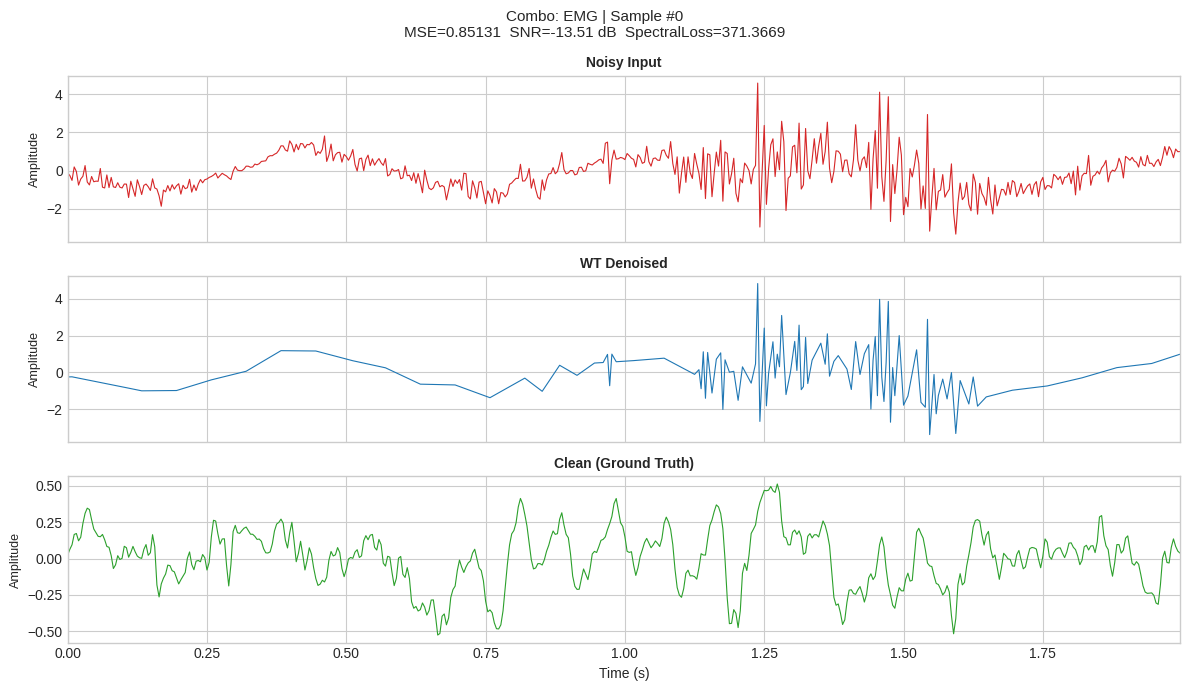

Saved → /kaggle/working/wt_denoising_results/time_domain_emg_s0.png


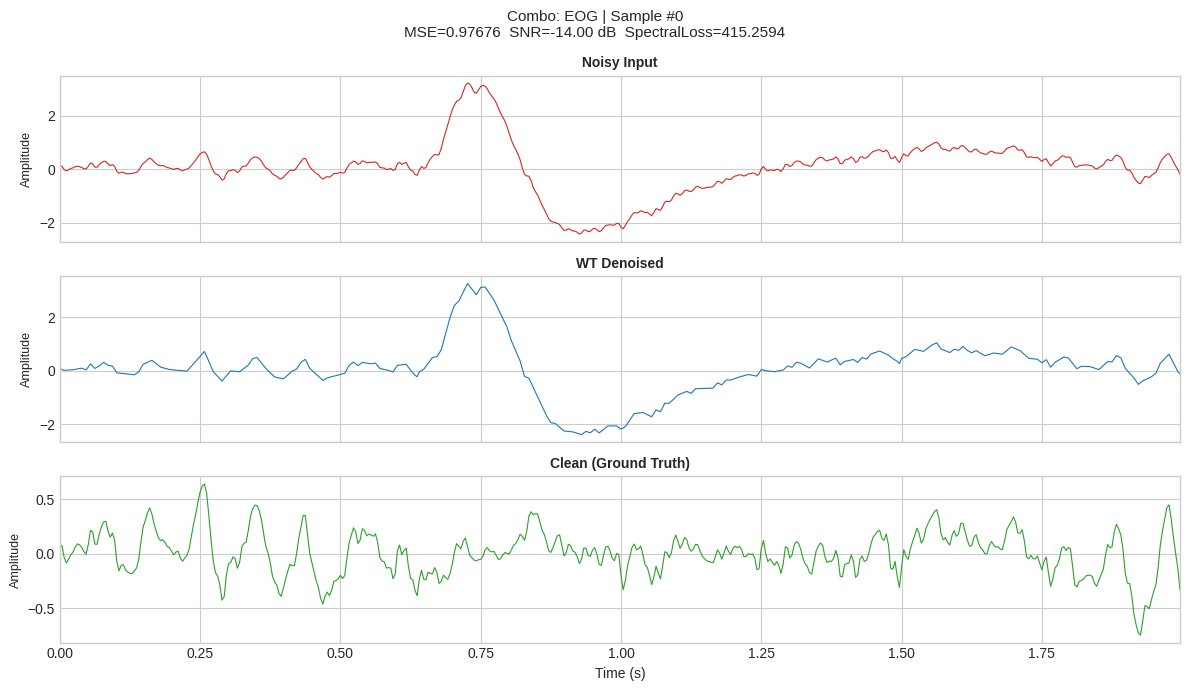

Saved → /kaggle/working/wt_denoising_results/time_domain_eog_s0.png


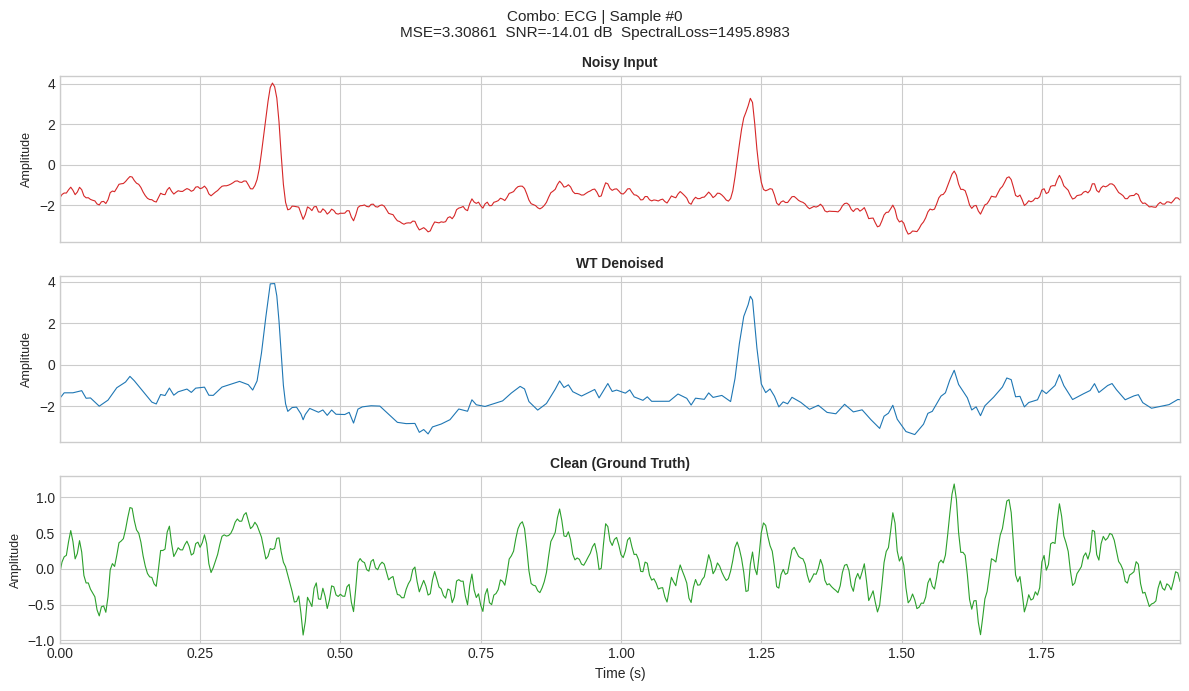

Saved → /kaggle/working/wt_denoising_results/time_domain_ecg_s0.png


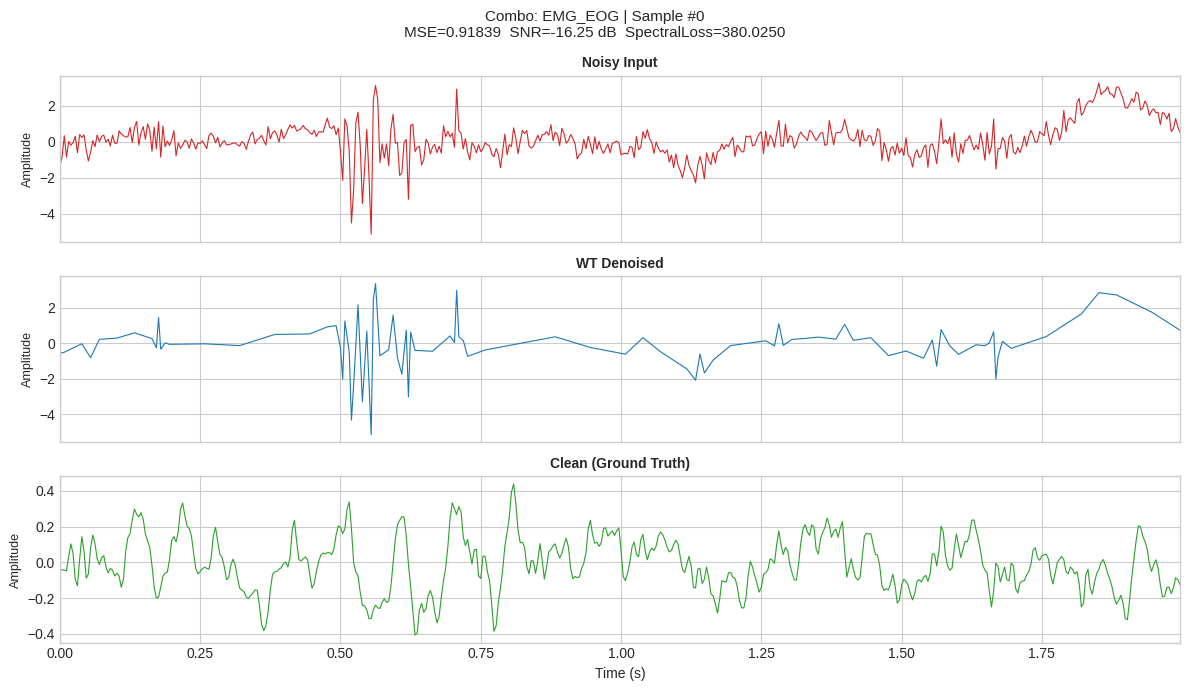

Saved → /kaggle/working/wt_denoising_results/time_domain_emg_eog_s0.png


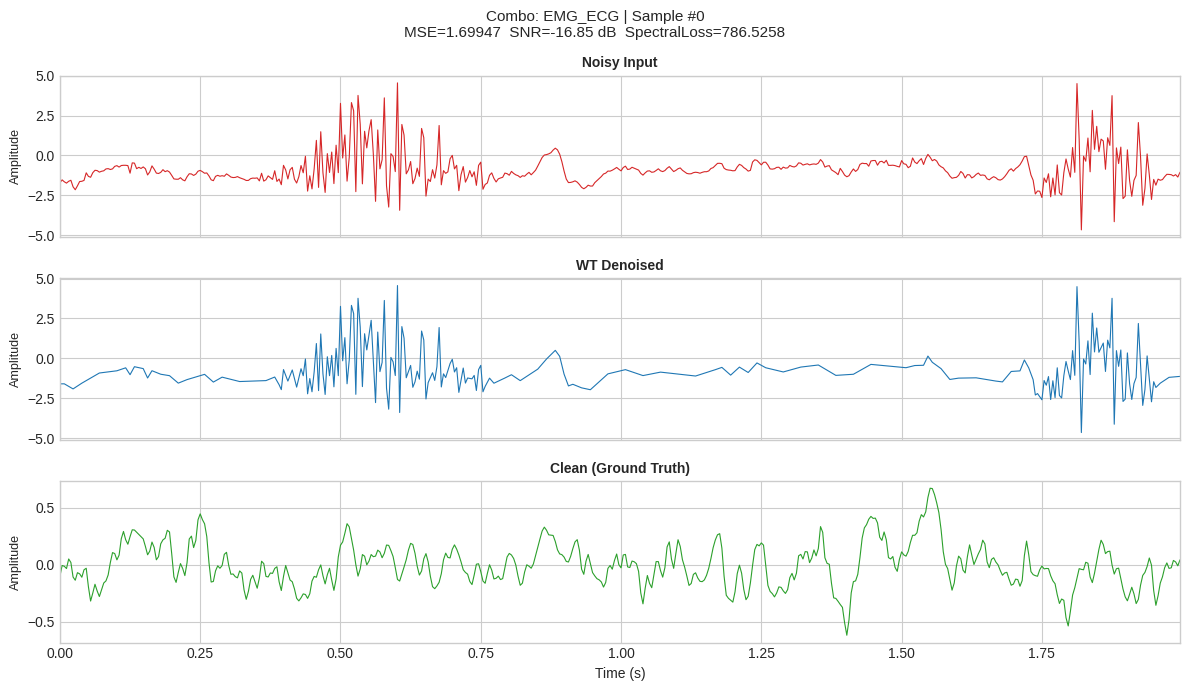

Saved → /kaggle/working/wt_denoising_results/time_domain_emg_ecg_s0.png


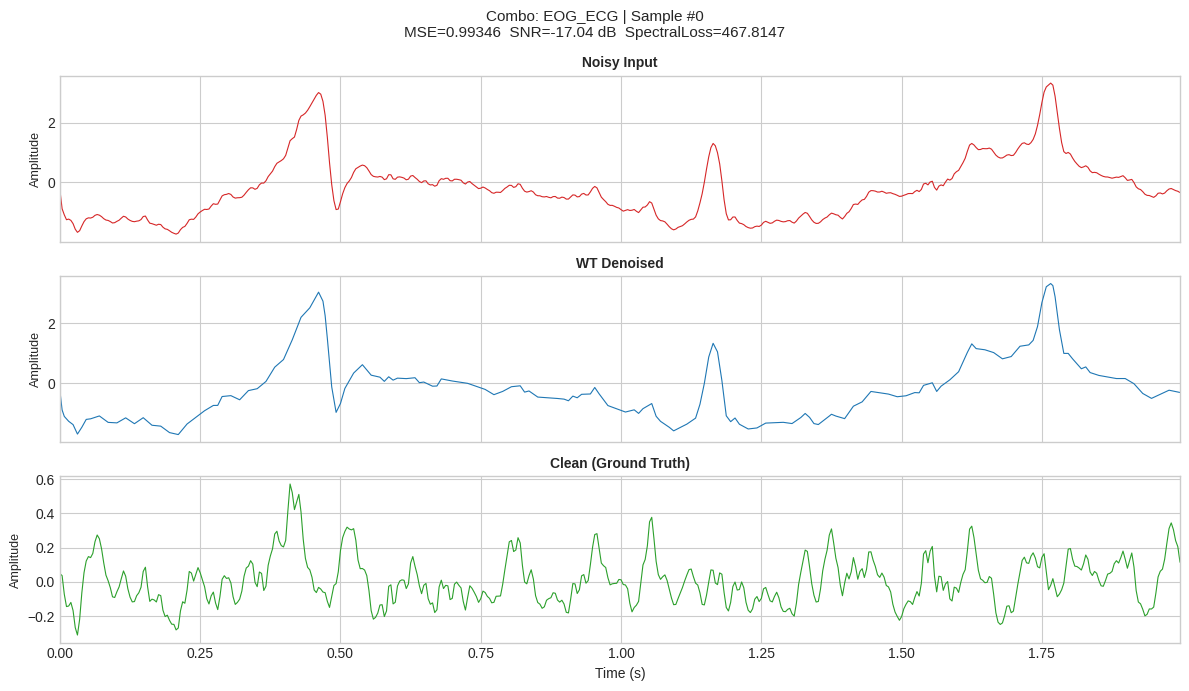

Saved → /kaggle/working/wt_denoising_results/time_domain_eog_ecg_s0.png


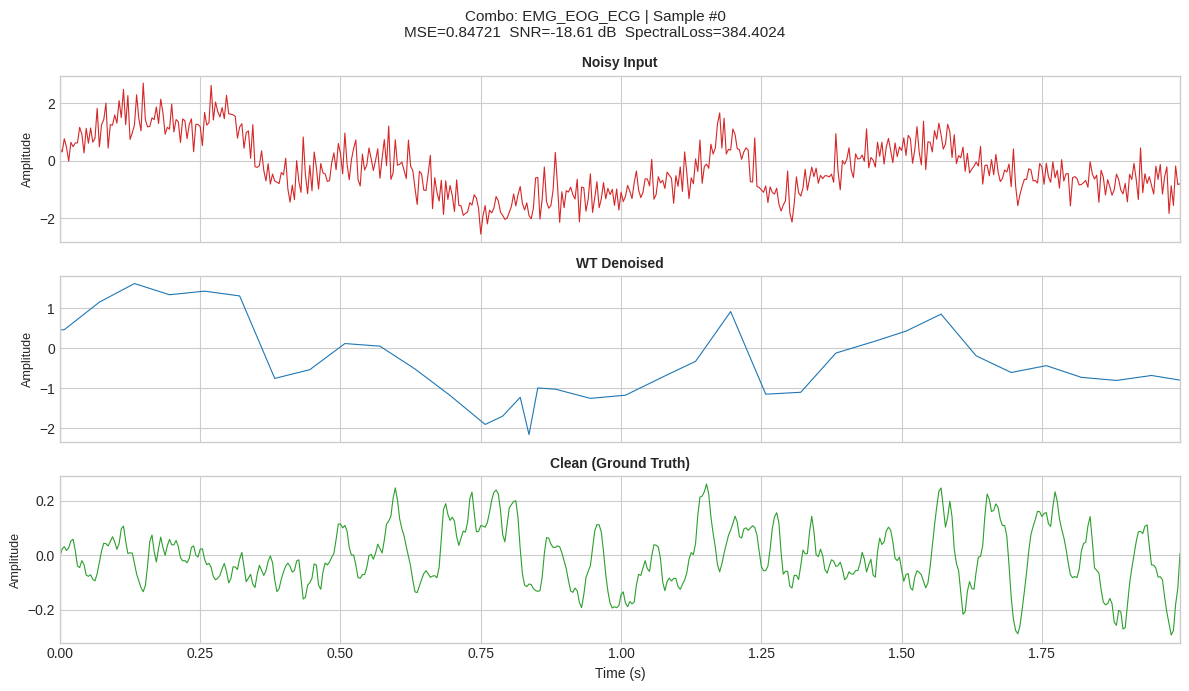

Saved → /kaggle/working/wt_denoising_results/time_domain_emg_eog_ecg_s0.png


In [8]:
def plot_reconstruction(combo: str, idx: int = 0, fs: int = FS):
    """
    Plot noisy, denoised, and clean signals in the time domain for one sample.
    """
    clean    = clean_store[combo][idx]
    denoised = denoised_store[combo][idx]

    # Re-compute noisy for visualisation (not stored to save RAM)
    h5_path = os.path.join(INPUT_DIR, f'{combo}_test.h5')
    with h5py.File(h5_path, 'r') as f:
        noisy = f['noisy'][idx]

    t = np.arange(len(clean)) / fs  # time axis in seconds

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    labels  = ['Noisy Input', 'WT Denoised', 'Clean (Ground Truth)']
    signals = [noisy, denoised, clean]
    colors  = ['#d62728', '#1f77b4', '#2ca02c']

    for ax, sig, lbl, col in zip(axes, signals, labels, colors):
        ax.plot(t, sig, color=col, linewidth=0.8)
        ax.set_ylabel('Amplitude', fontsize=9)
        ax.set_title(lbl, fontsize=10, fontweight='bold')
        ax.set_xlim(t[0], t[-1])

    axes[-1].set_xlabel('Time (s)', fontsize=10)
    mse = compute_mse(clean, denoised)
    snr = compute_snr(clean, denoised)
    spec = compute_spectral_loss(clean, denoised)
    fig.suptitle(
        f'Combo: {combo.upper()} | Sample #{idx}\n'
        f'MSE={mse:.5f}  SNR={snr:+.2f} dB  SpectralLoss={spec:.4f}',
        fontsize=11,
    )
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f'time_domain_{combo}_s{idx}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


# Plot one example per combo
for combo in tqdm(COMBOS, desc='Plotting time-domain', unit='combo'):
    plot_reconstruction(combo, idx=0)

### 7-B  Frequency-domain (Spectral) comparison

Plotting spectra:   0%|          | 0/7 [00:00<?, ?combo/s]

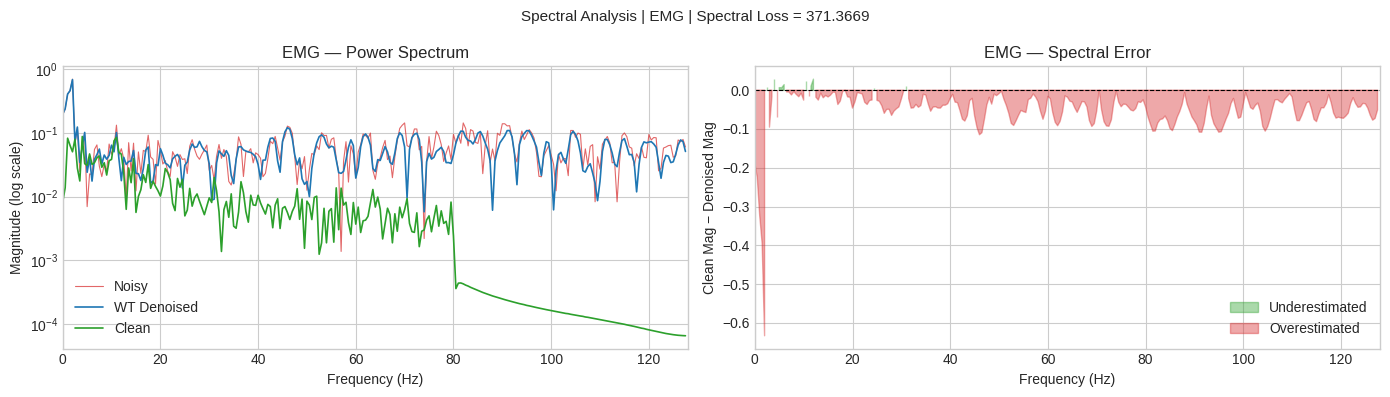

Saved → /kaggle/working/wt_denoising_results/spectrum_emg_s0.png


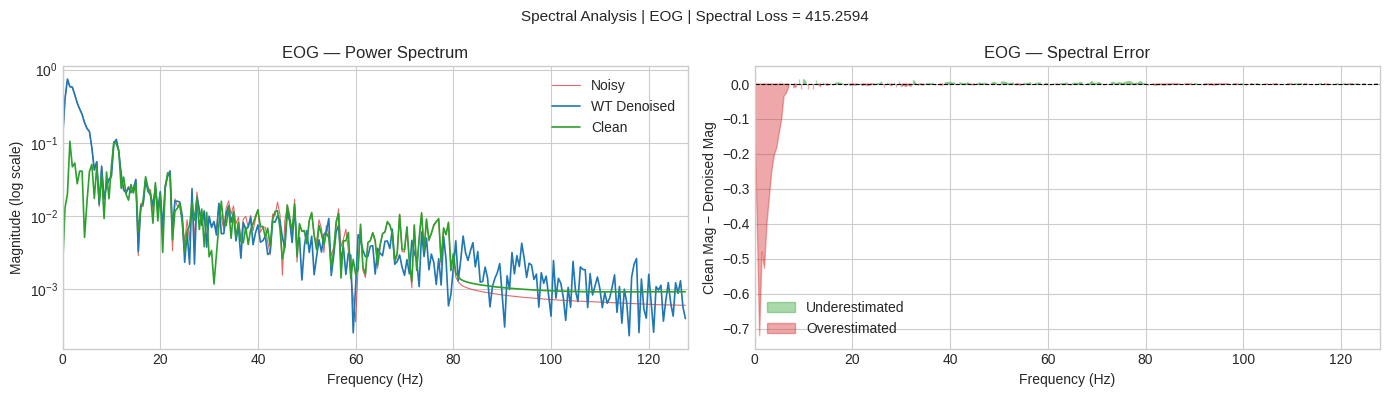

Saved → /kaggle/working/wt_denoising_results/spectrum_eog_s0.png


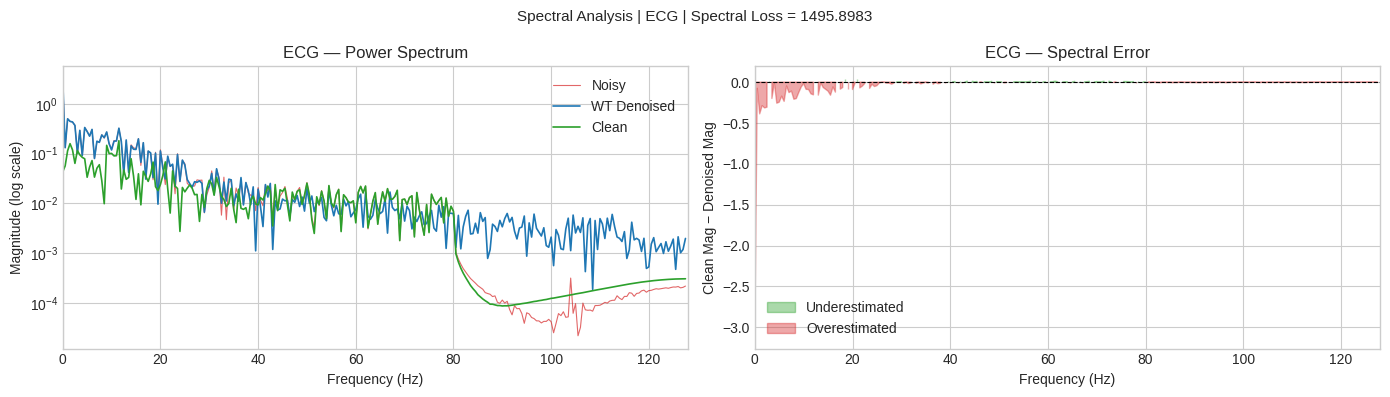

Saved → /kaggle/working/wt_denoising_results/spectrum_ecg_s0.png


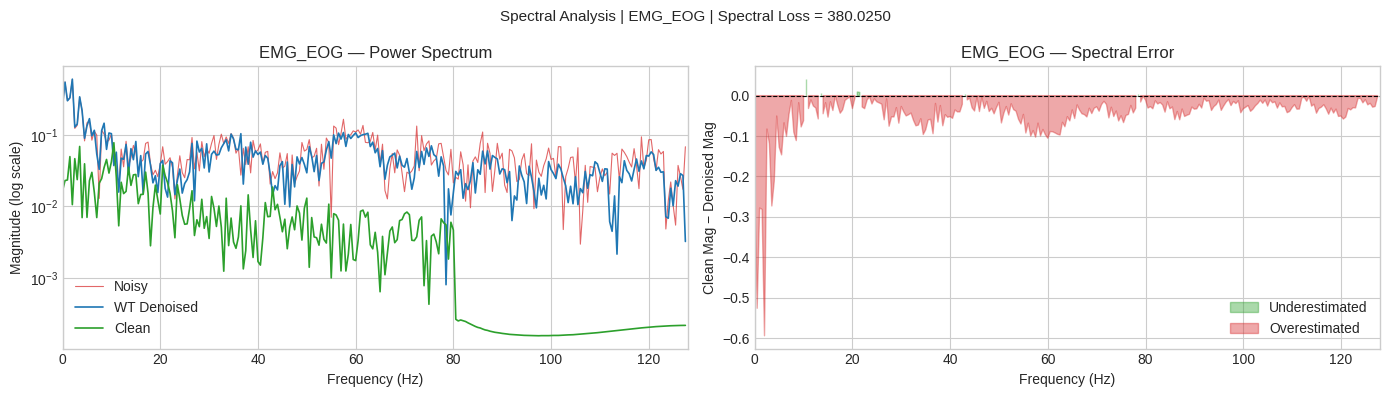

Saved → /kaggle/working/wt_denoising_results/spectrum_emg_eog_s0.png


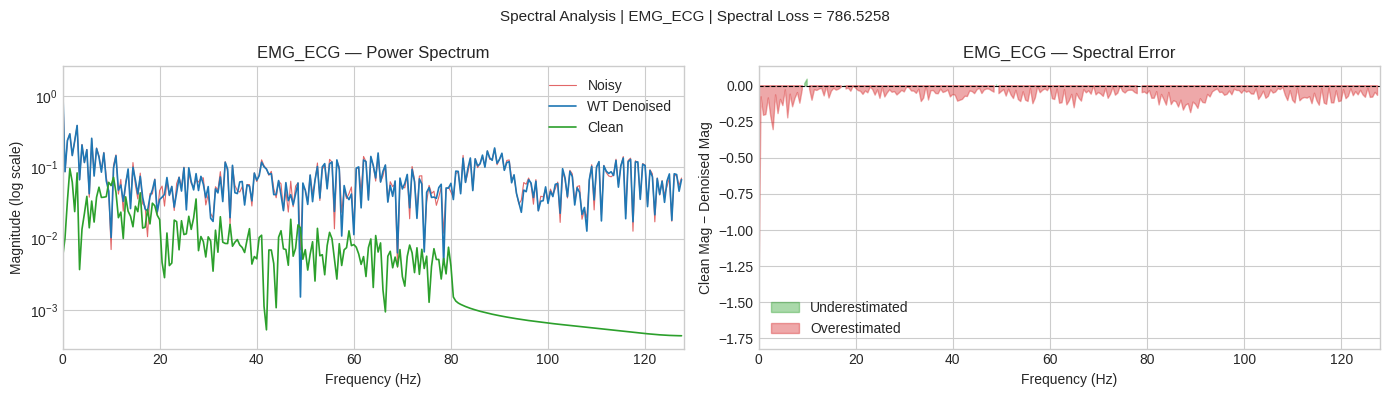

Saved → /kaggle/working/wt_denoising_results/spectrum_emg_ecg_s0.png


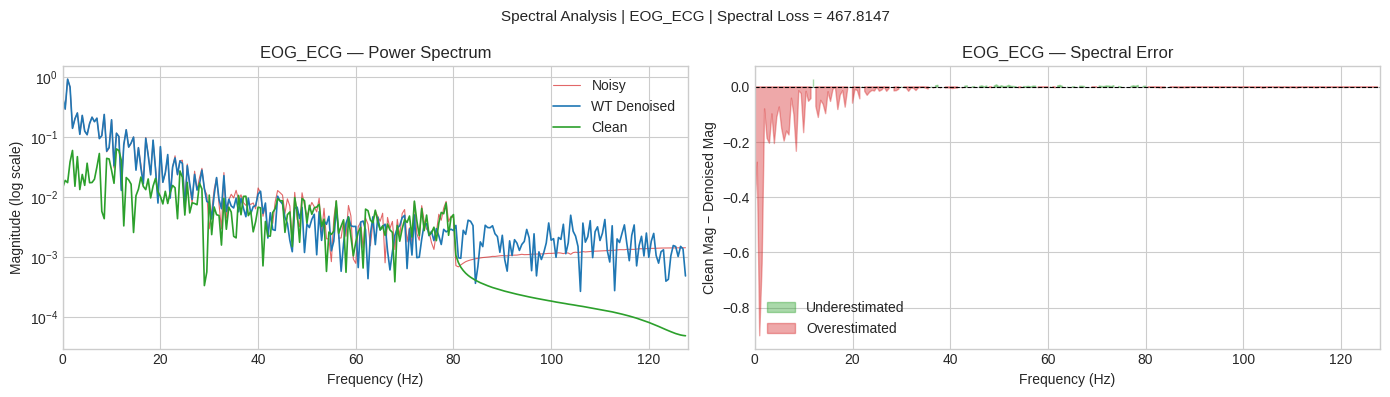

Saved → /kaggle/working/wt_denoising_results/spectrum_eog_ecg_s0.png


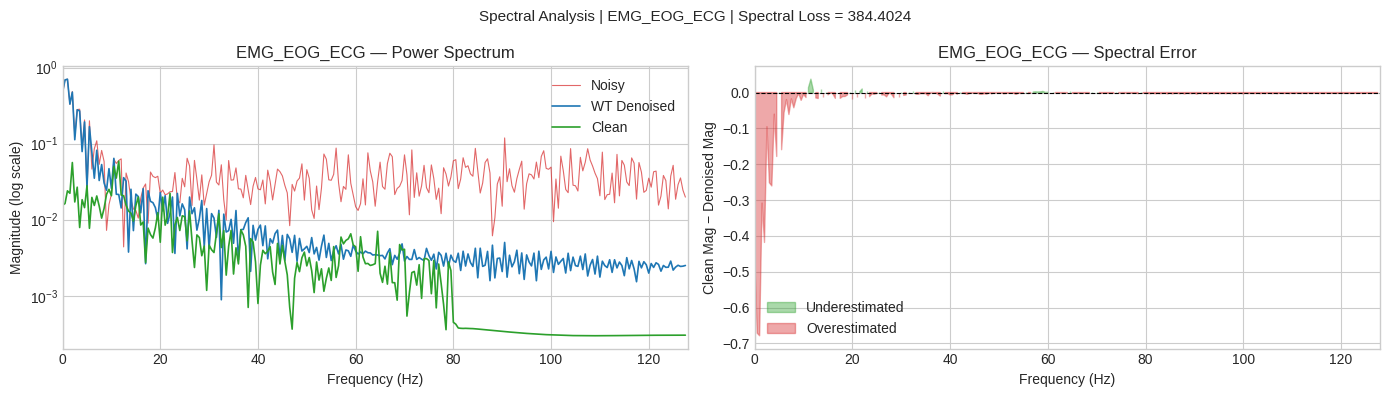

Saved → /kaggle/working/wt_denoising_results/spectrum_emg_eog_ecg_s0.png


In [9]:
def plot_spectrum(combo: str, idx: int = 0, fs: int = FS):
    """
    Compare power spectra of noisy, denoised, and clean signals.
    Shows exactly where spectral loss arises.
    """
    clean    = clean_store[combo][idx]
    denoised = denoised_store[combo][idx]

    h5_path = os.path.join(INPUT_DIR, f'{combo}_test.h5')
    with h5py.File(h5_path, 'r') as f:
        noisy = f['noisy'][idx]

    N   = len(clean)
    fq  = fftfreq(N, d=1/fs)[:N//2]

    def mag_spectrum(x):
        return (2 / N) * np.abs(fft(x))[:N//2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: magnitude spectra
    ax = axes[0]
    ax.semilogy(fq, mag_spectrum(noisy),    color='#d62728', lw=0.8, alpha=0.7, label='Noisy')
    ax.semilogy(fq, mag_spectrum(denoised), color='#1f77b4', lw=1.2, label='WT Denoised')
    ax.semilogy(fq, mag_spectrum(clean),    color='#2ca02c', lw=1.2, label='Clean')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude (log scale)')
    ax.set_title(f'{combo.upper()} — Power Spectrum')
    ax.legend()
    ax.set_xlim(0, fs // 2)

    # Right: spectral error (|Clean| - |Denoised|)
    ax2 = axes[1]
    spectral_err = mag_spectrum(clean) - mag_spectrum(denoised)
    ax2.fill_between(fq, spectral_err, 0,
                     where=(spectral_err >= 0), color='#2ca02c', alpha=0.4, label='Underestimated')
    ax2.fill_between(fq, spectral_err, 0,
                     where=(spectral_err <  0), color='#d62728', alpha=0.4, label='Overestimated')
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Clean Mag − Denoised Mag')
    ax2.set_title(f'{combo.upper()} — Spectral Error')
    ax2.legend()
    ax2.set_xlim(0, fs // 2)

    spec_loss = compute_spectral_loss(clean, denoised)
    fig.suptitle(f'Spectral Analysis | {combo.upper()} | Spectral Loss = {spec_loss:.4f}', fontsize=11)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f'spectrum_{combo}_s{idx}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


for combo in tqdm(COMBOS, desc='Plotting spectra', unit='combo'):
    plot_spectrum(combo, idx=0)

### 7-C  Metric bar charts across all combos

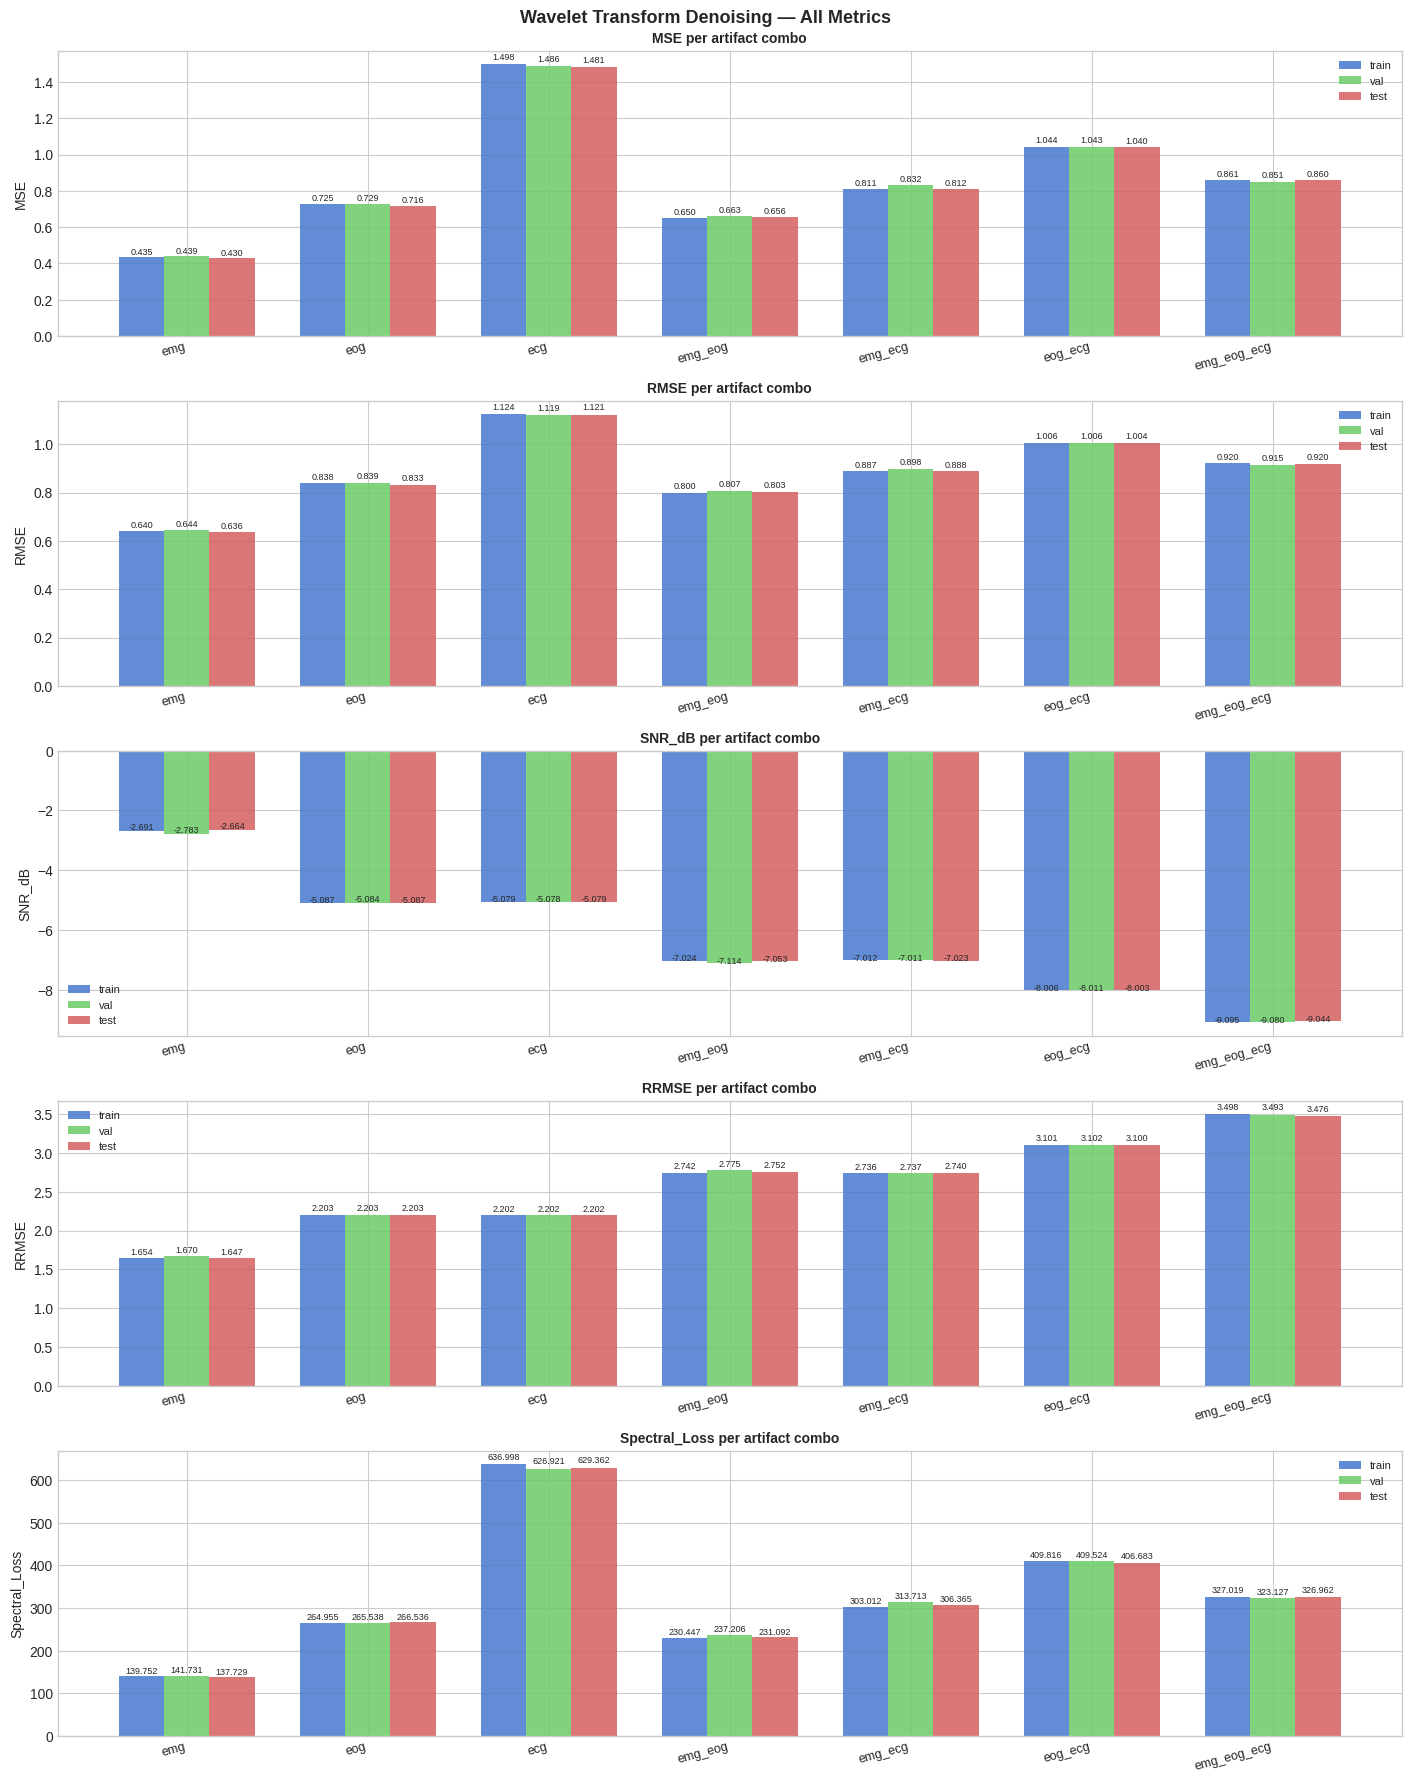

Saved → /kaggle/working/wt_denoising_results/metric_bars_all.png


In [10]:
metrics_to_plot = ['MSE', 'RMSE', 'SNR_dB', 'RRMSE', 'Spectral_Loss']
colors_splits   = {'train': '#4878CF', 'val': '#6ACC65', 'test': '#D65F5F'}

fig, axes = plt.subplots(len(metrics_to_plot), 1,
                         figsize=(14, 3.5 * len(metrics_to_plot)),
                         constrained_layout=True)

x = np.arange(len(COMBOS))
width = 0.25

for ax, metric in zip(axes, metrics_to_plot):
    for k, split in enumerate(SPLITS):
        vals = results_df[results_df['split'] == split][metric].values
        bars = ax.bar(x + k * width, vals, width,
                      label=split, color=colors_splits[split], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=6.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(COMBOS, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(f'{metric} per artifact combo', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Wavelet Transform Denoising — All Metrics', fontsize=13, fontweight='bold', y=1.01)
save_path = os.path.join(OUTPUT_DIR, 'metric_bars_all.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

### 7-D  Spectral Loss heatmap (combos × splits)

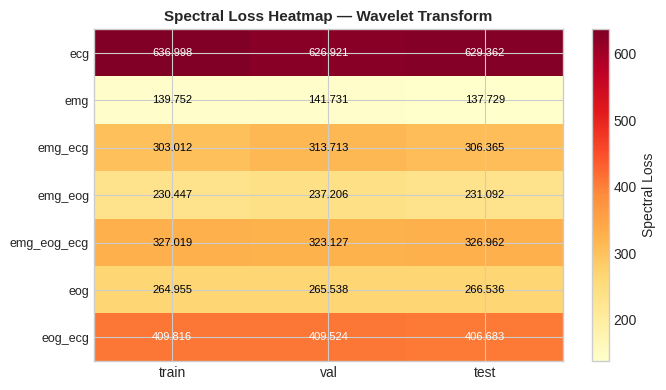

Saved → /kaggle/working/wt_denoising_results/spectral_loss_heatmap.png


In [11]:
pivot = results_df.pivot(index='combo', columns='split', values='Spectral_Loss')[SPLITS]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Spectral Loss', fontsize=10)

ax.set_xticks(range(len(SPLITS)))
ax.set_xticklabels(SPLITS, fontsize=10)
ax.set_yticks(range(len(COMBOS)))
ax.set_yticklabels(pivot.index.tolist(), fontsize=9)

for i in range(len(COMBOS)):
    for j in range(len(SPLITS)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}",
                ha='center', va='center', fontsize=8,
                color='black' if pivot.values[i, j] < pivot.values.max() * 0.6 else 'white')

ax.set_title('Spectral Loss Heatmap — Wavelet Transform', fontsize=11, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'spectral_loss_heatmap.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

## 8 — Ablation: Wavelet Family & Threshold Type

Reproduces the sweep from Table I of the paper on a small subset (first 200 test samples of `emg`) for speed.

In [12]:
ABLATION_COMBO  = 'emg'
ABLATION_N      = 200   # number of test samples to use

# Wavelets from the paper: Biorthogonal, Reverse Biorthogonal, Coiflet
ABLATION_WAVELETS    = ['bior2.2', 'rbio2.2', 'coif2']
ABLATION_WAVELET_LBL = ['Biorthogonal', 'Reverse Biorthogonal', 'Coiflet']
ABLATION_THRESHOLDS  = ['hard', 'soft']

h5_path = os.path.join(INPUT_DIR, f'{ABLATION_COMBO}_test.h5')
with h5py.File(h5_path, 'r') as f:
    ab_clean = f['clean'][:ABLATION_N]
    ab_noisy = f['noisy'][:ABLATION_N]

ablation_rows = []

total_iters = len(ABLATION_WAVELETS) * len(ABLATION_THRESHOLDS)
with tqdm(total=total_iters, desc='Ablation sweep') as pbar:
    for wav, wav_lbl in zip(ABLATION_WAVELETS, ABLATION_WAVELET_LBL):
        for thresh in ABLATION_THRESHOLDS:
            pbar.set_postfix(wavelet=wav_lbl, threshold=thresh)
            den = np.array(
                [wavelet_denoise(ab_noisy[i], wavelet=wav, mode=thresh)
                 for i in range(ABLATION_N)]
            )
            m = evaluate_batch(ab_clean, den)
            ablation_rows.append({'Wavelet': wav_lbl, 'Threshold': thresh, **m})
            pbar.update(1)

ablation_df = pd.DataFrame(ablation_rows)
print('\n=== Ablation Results (first 200 test samples of EMG combo) ===')
display(ablation_df)

ab_csv = os.path.join(OUTPUT_DIR, 'wt_ablation.csv')
ablation_df.to_csv(ab_csv, index=False)
print(f'Saved → {ab_csv}')

Ablation sweep:   0%|          | 0/6 [00:00<?, ?it/s]


=== Ablation Results (first 200 test samples of EMG combo) ===


,Wavelet,Threshold,MSE,RMSE,SNR_dB,RRMSE,Spectral_Loss
0,Biorthogonal,hard,0.44145,0.64564,-2.75577,1.66906,145.65052
1,Biorthogonal,soft,0.30422,0.53153,-0.98747,1.31315,94.32707
2,Reverse Biorthogonal,hard,0.44171,0.64456,-2.70569,1.58793,138.58354
3,Reverse Biorthogonal,soft,0.32798,0.55236,-1.26945,1.31781,95.57825
4,Coiflet,hard,0.40558,0.61441,-2.25786,1.56206,136.31539
5,Coiflet,soft,0.29638,0.52273,-0.77266,1.27139,99.63438


Saved → /kaggle/working/wt_denoising_results/wt_ablation.csv


## 9 — DWT Coefficient Visualisation
Shows the wavelet decomposition and which detail sub-bands get thresholded.

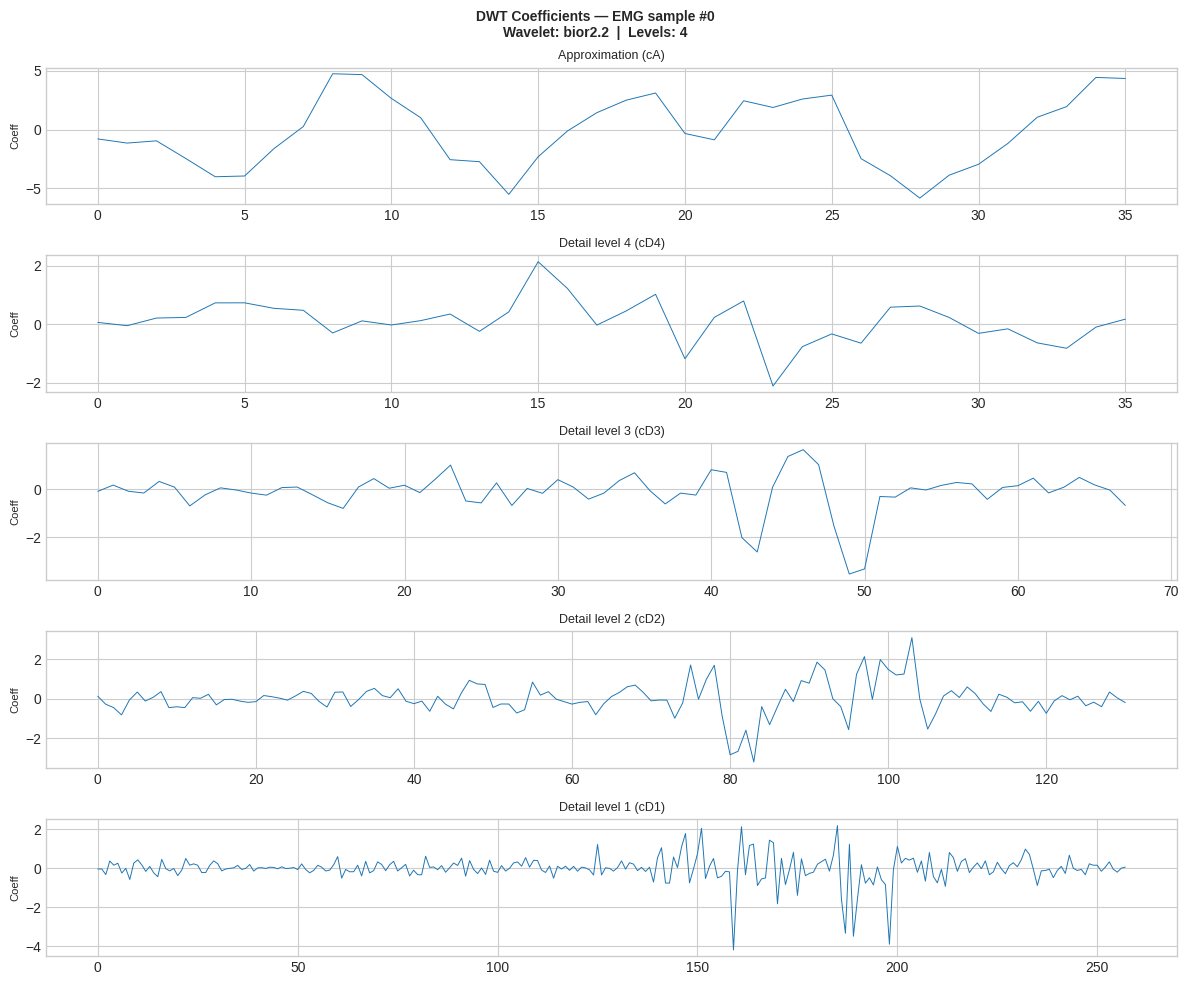

Saved → /kaggle/working/wt_denoising_results/dwt_coeffs_emg_s0.png


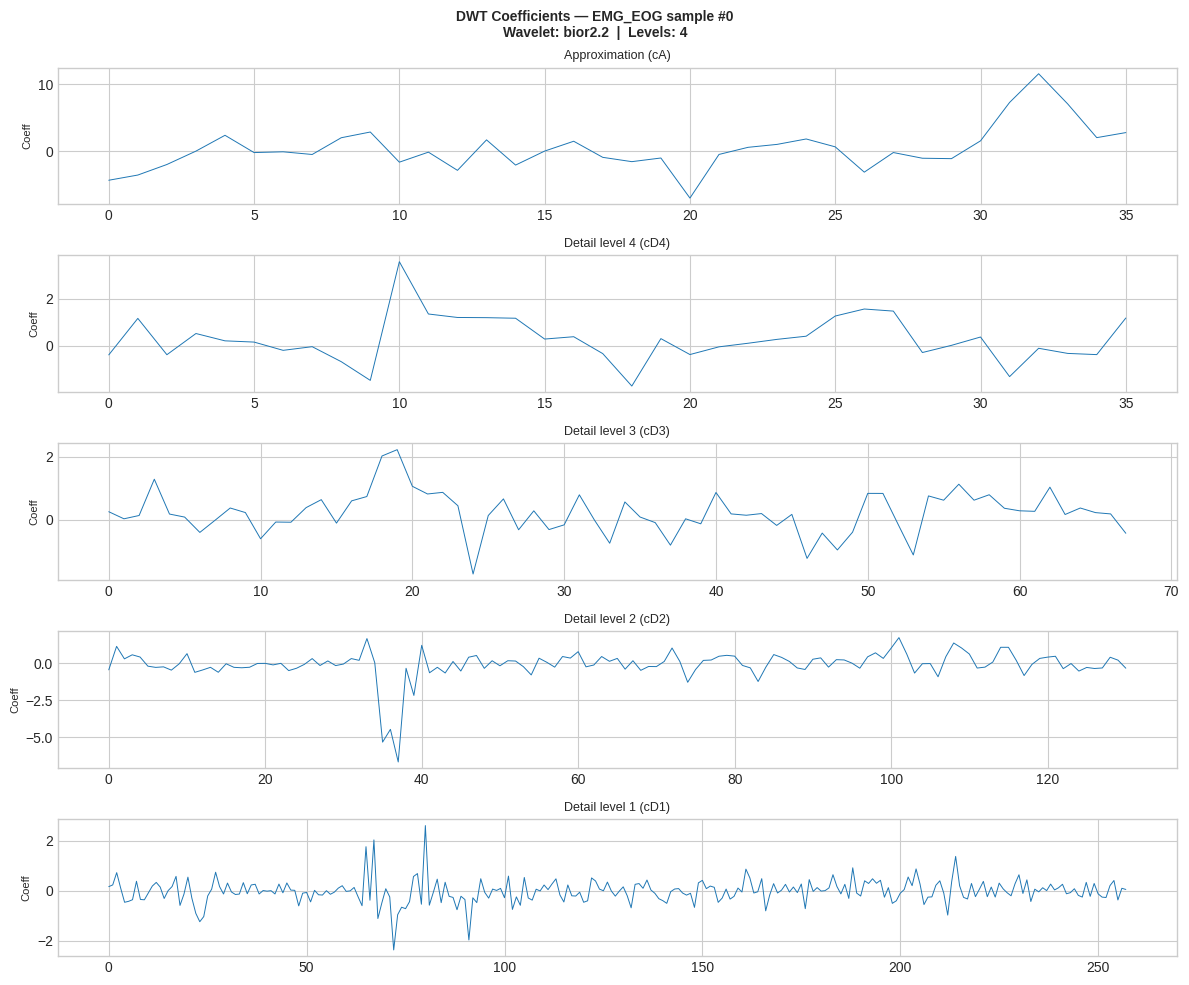

Saved → /kaggle/working/wt_denoising_results/dwt_coeffs_emg_eog_s0.png


In [13]:
def plot_dwt_coefficients(combo: str, idx: int = 0):
    h5_path = os.path.join(INPUT_DIR, f'{combo}_test.h5')
    with h5py.File(h5_path, 'r') as f:
        noisy = f['noisy'][idx]

    coeffs = pywt.wavedec(noisy, WAVELET, level=DECOMP_LEVEL)
    n_levels = len(coeffs)  # 1 approx + DECOMP_LEVEL detail

    fig, axes = plt.subplots(n_levels, 1, figsize=(12, 2 * n_levels), sharex=False)
    labels = ['Approximation (cA)'] + [f'Detail level {DECOMP_LEVEL - i} (cD{DECOMP_LEVEL - i})'
                                        for i in range(DECOMP_LEVEL)]

    for ax, c, lbl in zip(axes, coeffs, labels):
        ax.plot(c, linewidth=0.7, color='#1f77b4')
        ax.set_title(lbl, fontsize=9)
        ax.set_ylabel('Coeff', fontsize=8)

    fig.suptitle(f'DWT Coefficients — {combo.upper()} sample #{idx}\n'
                 f'Wavelet: {WAVELET}  |  Levels: {DECOMP_LEVEL}',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f'dwt_coeffs_{combo}_s{idx}.png')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')

plot_dwt_coefficients('emg',     idx=0)
plot_dwt_coefficients('emg_eog', idx=0)

## 10 — Final Summary

In [14]:
print('=' * 65)
print('   Wavelet Transform Denoising — Final Summary')
print('=' * 65)
print(f'  Wavelet       : {WAVELET}  (Biorthogonal)')
print(f'  Threshold     : {THRESHOLD_TYPE}')
print(f'  Rule          : {THRESHOLD_RULE} (VisuShrink)')
print(f'  Decomp levels : {DECOMP_LEVEL}')
print(f'  Sampling rate : {FS} Hz')
print(f'  Combos tested : {len(COMBOS)}')
print(f'  Splits        : {SPLITS}')
print('─' * 65)

test_means = results_df[results_df['split'] == 'test'][metrics_to_plot].mean()
for m, v in test_means.items():
    print(f'  Mean {m:<18}: {v:.5f}')

print('─' * 65)
print(f'  Outputs saved to: {OUTPUT_DIR}')
print('=' * 65)

# List all saved files
saved = glob.glob(os.path.join(OUTPUT_DIR, '*'))
print(f'\n  {len(saved)} file(s) saved:')
for p in sorted(saved):
    print(f'    {os.path.basename(p)}')

   Wavelet Transform Denoising — Final Summary
  Wavelet       : bior2.2  (Biorthogonal)
  Threshold     : hard
  Rule          : universal (VisuShrink)
  Decomp levels : 4
  Sampling rate : 256 Hz
  Combos tested : 7
  Splits        : ['train', 'val', 'test']
─────────────────────────────────────────────────────────────────
  Mean MSE               : 0.85652
  Mean RMSE              : 0.88650
  Mean SNR_dB            : -6.27895
  Mean RRMSE             : 2.58861
  Mean Spectral_Loss     : 329.24700
─────────────────────────────────────────────────────────────────
  Outputs saved to: /kaggle/working/wt_denoising_results

  20 file(s) saved:
    dwt_coeffs_emg_eog_s0.png
    dwt_coeffs_emg_s0.png
    metric_bars_all.png
    spectral_loss_heatmap.png
    spectrum_ecg_s0.png
    spectrum_emg_ecg_s0.png
    spectrum_emg_eog_ecg_s0.png
    spectrum_emg_eog_s0.png
    spectrum_emg_s0.png
    spectrum_eog_ecg_s0.png
    spectrum_eog_s0.png
    time_domain_ecg_s0.png
    time_domain_emg_ecg_s0